In [1]:
# =========================================================
# CELL 1 - IMPORT LIBRARY + KONEKSI SUPABASE
# =========================================================
import os
import re
import json
import sys
import scipy.sparse as sp
import pandas as pd
import numpy as np

from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from dotenv import load_dotenv
from supabase import create_client
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.metrics.pairwise import cosine_similarity

BACKEND_DIR = next(
    path for path in (Path.cwd(), Path.cwd().parent, Path.cwd() / "backend")
    if (path / "src" / "preprocessing").is_dir()
)
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from src.preprocessing.stopwords import get_stopwords

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_SERVICE_ROLE_KEY") or os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

SOURCE_TABLE = "cleaned_papers_results"
SIMILARITY_TABLE = "similarity_results"

print("✅ Supabase client siap")

✅ Supabase client siap


In [2]:
# =========================================================
# CELL 2 - LOAD FILE VSM HASIL TF-IDF
# =========================================================
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
tfidf_dir = os.path.join(base_dir, "data", "tfidf")
results_dir = os.path.join(base_dir, "data", "cosine_results")

os.makedirs(results_dir, exist_ok=True)

tfidf_matrix = sp.load_npz(os.path.join(tfidf_dir, "tfidf_matrix.npz"))

with open(os.path.join(tfidf_dir, "tfidf_terms.json"), "r", encoding="utf-8") as file:
    terms = json.load(file)

with open(os.path.join(tfidf_dir, "tfidf_doc_ids.json"), "r", encoding="utf-8") as file:
    doc_ids = json.load(file)

with open(os.path.join(tfidf_dir, "idf_scores.json"), "r", encoding="utf-8") as file:
    idf_scores = json.load(file)

tfidf_documents = pd.read_csv(os.path.join(tfidf_dir, "tfidf_documents.csv"))

doc_ids = [int(doc_id) for doc_id in doc_ids]

print("✅ File VSM berhasil dimuat")
print("Matrix TF-IDF:", tfidf_matrix.shape)
print("Jumlah terms:", len(terms))
print("Jumlah doc_ids:", len(doc_ids))

✅ File VSM berhasil dimuat
Matrix TF-IDF: (200, 1733)
Jumlah terms: 1733
Jumlah doc_ids: 200


In [3]:
# =========================================================
# CELL 3 - LOAD METADATA ARTIKEL DARI SUPABASE
# =========================================================
all_data = []
batch_size = 1000
offset = 0

selected_columns = """
id,
title,
abstract,
authors,
year,
source,
category,
pdf_url,
url,
scrape_status
"""

while True:
    response = (
        supabase.table(SOURCE_TABLE)
        .select(selected_columns)
        .range(offset, offset + batch_size - 1)
        .execute()
    )

    batch = response.data or []

    if not batch:
        break

    all_data.extend(batch)

    if len(batch) < batch_size:
        break

    offset += batch_size

metadata_df = pd.DataFrame(all_data)

if metadata_df.empty:
    raise ValueError("❌ Data cleaned_papers_results kosong.")

metadata_df["id"] = metadata_df["id"].astype("int64")

doc_index = pd.DataFrame({"id": doc_ids})
doc_index = doc_index.merge(metadata_df, on="id", how="left")
doc_index = doc_index.merge(
    tfidf_documents[["id", "document_text"]],
    on="id",
    how="left",
)

for col in ["title", "abstract", "authors", "source", "category", "pdf_url", "url", "scrape_status", "document_text"]:
    if col in doc_index.columns:
        doc_index[col] = doc_index[col].fillna("")

print("✅ Metadata artikel siap")
print("Jumlah doc_index:", len(doc_index))

doc_index.head(3)

✅ Metadata artikel siap
Jumlah doc_index: 200


,id,title,abstract,authors,year,source,category,pdf_url,url,scrape_status,document_text
0,2,Machine learning for microbiologists,… how to evaluate a machine learning model and...,"F Asnicar, AM Thomas, A Passerini…",2024,Nature Reviews …,machine learning,https://www.nature.com/articles/s41579-023-009...,https://www.nature.com/articles/s41579-023-009...,metadata_only,machine learning microbiologists how evaluate ...
1,3,Amnesiac machine learning,… It gives EU residents the ability to request...,"L Graves, V Nagisetty, V Ganesh",2021,… of the AAAI conference on artificial …,machine learning,https://ojs.aaai.org/index.php/AAAI/article/do...,https://ojs.aaai.org/index.php/AAAI/article/vi...,pdf_downloaded,amnesiac machine learning gives eu residents a...
2,4,Designing nanotheranostics with machine learning,"… As a key branch of artificial intelligence, ...","L Rao, Y Yuan, X Shen, G Yu, X Chen",2024,Nature Nanotechnology,machine learning,https://www.nature.com/articles/s41565-024-017...,https://www.nature.com/articles/s41565-024-017...,metadata_only,designing nanotheranostics machine learning ke...


In [4]:
# =========================================================
# CELL 4 - VALIDASI MATRIX DAN DOKUMEN
# =========================================================
if tfidf_matrix.shape[0] != len(doc_index):
    raise ValueError(
        f"Jumlah baris matrix ({tfidf_matrix.shape[0]}) tidak sama dengan doc_index ({len(doc_index)})"
    )

print("✅ Matrix dan doc_index sesuai")

✅ Matrix dan doc_index sesuai


In [5]:
# =========================================================
# CELL 5 - STOPWORDS + STEMMER
# =========================================================
stop_words = get_stopwords()

stemmer = StemmerFactory().create_stemmer()

print("✅ Stopwords dan stemmer siap")

✅ Stopwords dan stemmer siap


In [6]:
# =========================================================
# CELL 6 - FUNGSI QUERY VECTOR DAN COSINE
# =========================================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_query(query):
    cleaned = clean_text(query)
    tokens = cleaned.split()
    tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    tokens = [stemmer.stem(token) for token in tokens]
    return tokens

def build_query_vector(query_tokens):
    term_to_index = {term: index for index, term in enumerate(terms)}
    query_vector = np.zeros(len(terms), dtype=float)

    if not query_tokens:
        return query_vector.reshape(1, -1)

    total_terms = len(query_tokens)
    term_counts = Counter(query_tokens)

    for term, count in term_counts.items():
        if term in term_to_index:
            tf = count / total_terms
            idf = float(idf_scores.get(term, 0))
            query_vector[term_to_index[term]] = tf * idf

    return query_vector.reshape(1, -1)

def count_occurrence(document_text, query_tokens):
    document_tokens = str(document_text).split()
    return sum(document_tokens.count(term) for term in query_tokens)

def interpret_similarity(score, threshold=0.3):
    if score > 0.5:
        return "Relevan Tinggi"
    if score > threshold:
        return "Relevan Sedang"
    return "Rendah"

def is_direct_pdf(url):
    if pd.isna(url):
        return False

    url = str(url).lower()

    return (
        url.endswith(".pdf")
        or "/pdf/" in url
        or "arxiv.org/pdf" in url
        or "pmc.ncbi.nlm.nih.gov" in url
        or "jmlr.org" in url
    )

print("✅ Fungsi cosine siap")

✅ Fungsi cosine siap


In [7]:
# =========================================================
# CELL 7 - FUNGSI SEARCH SISTEM
# Query user vs dokumen gabungan title + abstract
# =========================================================
def search(query, top_k=10, min_occurrence=0, threshold=0.3):
    query_tokens = preprocess_query(query)
    empty_columns = [
        "rank", "id", "title", "abstract", "authors", "year", "source", "category",
        "pdf_url", "url", "scrape_status", "similarity_score", "occurrence",
        "interpretation", "is_pdf", "access_url" ]

    if not query_tokens:
        return pd.DataFrame(columns=empty_columns)

    query_vector = build_query_vector(query_tokens)
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    results = doc_index.copy()
    results["similarity_score"] = scores
    results["occurrence"] = results["document_text"].apply(lambda text: count_occurrence
        (text, query_tokens))
    results = results[results["similarity_score"] > 0].copy()

    if min_occurrence > 0:
        results = results[results["occurrence"] >= min_occurrence].copy()

    results = results.sort_values("similarity_score", ascending=False)
    results = results.head(top_k).reset_index(drop=True)
    results["rank"] = range(1, len(results) + 1)
    results["interpretation"] = results["similarity_score"].apply(
        lambda score: interpret_similarity(score, threshold))
    results["is_pdf"] = results["pdf_url"].apply(is_direct_pdf)
    results["access_url"] = results.apply(
        lambda row: row["pdf_url"] if row["is_pdf"] else row["url"],
        axis=1,)

    return results

print("✅ Fungsi search siap")

✅ Fungsi search siap


In [8]:
# =========================================================
# CELL 8 - TEST SEARCH
# =========================================================
query = "machine learning"
top_k = 10
min_occurrence = 0
threshold = 0.3

results = search(
    query=query,
    top_k=top_k,
    min_occurrence=min_occurrence,
    threshold=threshold,
)

results[
    [
        "rank",
        "id",
        "category",
        "title",
        "similarity_score",
        "occurrence",
        "interpretation",
        "access_url",
    ]
].head(10)

,rank,id,category,title,similarity_score,occurrence,interpretation,access_url
0,1,28,machine learning,"Penerapan Machine Learning, Deep Learning, Dan...",0.478416,12,Relevan Sedang,https://ejournal3.undip.ac.id/index.php/accoun...
1,2,6,machine learning,Machine learning and deep learning: C. Janiesc...,0.477245,12,Relevan Sedang,https://link.springer.com/content/pdf/10.1007/...
2,3,38,machine learning,Penerapan Machine Learning Untuk Mengategorika...,0.447773,9,Relevan Sedang,https://ejournal.stmik-time.ac.id/index.php/ju...
3,4,16,machine learning,An overview of machine learning classification...,0.435087,10,Relevan Sedang,https://www.bio-conferences.org/articles/bioco...
4,5,26,machine learning,Penerapan machine learning dalam prediksi ting...,0.407131,8,Relevan Sedang,https://jurnal.amikom.ac.id/index.php/joism/ar...
5,6,15,machine learning,Research on machine learning with algorithms a...,0.395302,8,Relevan Sedang,https://centurysciencepub.com/index.php/jtpes/...
6,7,49,machine learning,Penerapan Metode Machine Learning dalam Mengid...,0.392233,8,Relevan Sedang,https://ejournal.upbatam.ac.id/index.php/cbis/...
7,8,22,machine learning,Machine learning in chemical engineering: A pe...,0.391862,8,Relevan Sedang,https://onlinelibrary.wiley.com/doi/pdf/10.100...
8,9,20,machine learning,Machine learning and applications in microbiology,0.386032,8,Relevan Sedang,https://academic.oup.com/femsre/article-pdf/45...
9,10,27,machine learning,Tinjauan Pustaka Sistematis: Penerapan Metode ...,0.381816,8,Relevan Sedang,https://jurnal.polgan.ac.id/index.php/jmp/arti...


In [9]:
# =========================================================
# CELL 9 - SIMPAN HASIL SEARCH KE CSV
# =========================================================
filename = f"similarity_score_{query.replace(' ', '_')}.csv"
save_path = os.path.join(results_dir, filename)

results.to_csv(save_path, index=False)

print("✅ CSV hasil cosine tersimpan:", save_path)
print("Jumlah hasil:", len(results))

✅ CSV hasil cosine tersimpan: d:\Tugas Akhir\paperci_artikel\backend\data\cosine_results\similarity_score_machine_learning.csv
Jumlah hasil: 10


In [10]:
# =========================================================
# CELL 10 - HELPER UPSERT SUPABASE
# =========================================================
def to_records_safe(dataframe):
    return dataframe.where(pd.notnull(dataframe), None).to_dict(orient="records")

def upsert_batches(table_name, records, on_conflict, batch_size=500):
    total = len(records)

    if total == 0:
        print(f"⚠️ Tidak ada data untuk disimpan ke {table_name}")
        return

    for start in range(0, total, batch_size):
        batch = records[start:start + batch_size]

        supabase.table(table_name).upsert(
            batch,
            on_conflict=on_conflict,
        ).execute()

        print(f"  → Batch {start // batch_size + 1}: {len(batch)} data")

    print(f"✅ Upsert {total} data ke {table_name}")

In [11]:
# =========================================================
# CELL 11 - SIMPAN HASIL COSINE KE SUPABASE
# target table: similarity_results
# unique index disarankan: article_id, compared_text
# =========================================================
def save_results_to_supabase(results, query):
    if results.empty:
        print("⚠️ Tidak ada hasil untuk disimpan.")
        return

    ts = datetime.now(timezone.utc).isoformat()

    payload = pd.DataFrame({
        "article_id": results["id"].astype("int64"),
        "compared_text": query,
        "similarity_score": results["similarity_score"].round(6).astype(float),
        "created_at": ts,
    })

    records = to_records_safe(payload)

    upsert_batches(
        table_name=SIMILARITY_TABLE,
        records=records,
        on_conflict="article_id,compared_text",
        batch_size=500,
    )

save_results_to_supabase(results, query)

  → Batch 1: 10 data
✅ Upsert 10 data ke similarity_results


In [12]:
# =========================================================
# CELL 12 - RUN QUERY PROPOSAL
# =========================================================
queries_proposal = [
    "machine learning",
    "web application",
    "cyber security",
    "mobile application",
]

for query in queries_proposal:
    print("=" * 70)
    print("Query:", query)

    results = search(
        query=query,
        top_k=10,
        min_occurrence=0,
        threshold=0.3,
    )

    filename = f"similarity_score_{query.replace(' ', '_')}.csv"
    save_path = os.path.join(results_dir, filename)

    results.to_csv(save_path, index=False)
    save_results_to_supabase(results, query)

    if results.empty:
        print("Tidak ada hasil.")
        continue

    display_cols = [
        "rank",
        "id",
        "category",
        "title",
        "similarity_score",
        "occurrence",
        "interpretation",
    ]

    print(results[display_cols].head(10))
    print("CSV:", save_path)

Query: machine learning
  → Batch 1: 10 data
✅ Upsert 10 data ke similarity_results
   rank  id          category  \
0     1  28  machine learning   
1     2   6  machine learning   
2     3  38  machine learning   
3     4  16  machine learning   
4     5  26  machine learning   
5     6  15  machine learning   
6     7  49  machine learning   
7     8  22  machine learning   
8     9  20  machine learning   
9    10  27  machine learning   

                                               title  similarity_score  \
0  Penerapan Machine Learning, Deep Learning, Dan...          0.478416   
1  Machine learning and deep learning: C. Janiesc...          0.477245   
2  Penerapan Machine Learning Untuk Mengategorika...          0.447773   
3  An overview of machine learning classification...          0.435087   
4  Penerapan machine learning dalam prediksi ting...          0.407131   
5  Research on machine learning with algorithms a...          0.395302   
6  Penerapan Metode Machine Learni

In [13]:
# =========================================================
# CELL 13 - VALIDASI SUPABASE
# =========================================================
check = (
    supabase.table(SIMILARITY_TABLE)
    .select("article_id, compared_text, similarity_score", count="exact")
    .limit(5)
    .execute()
)

print("✅ Total row similarity_results:", check.count)
check.data

✅ Total row similarity_results: 40


[{'article_id': 28,
  'compared_text': 'machine learning',
  'similarity_score': 0.478416},
 {'article_id': 6,
  'compared_text': 'machine learning',
  'similarity_score': 0.477245},
 {'article_id': 38,
  'compared_text': 'machine learning',
  'similarity_score': 0.447773},
 {'article_id': 16,
  'compared_text': 'machine learning',
  'similarity_score': 0.435087},
 {'article_id': 26,
  'compared_text': 'machine learning',
  'similarity_score': 0.407131}]

In [14]:
# =========================================================
# CELL 14 - COSINE MANUAL TITLE VS ABSTRAK
# Sesuai proposal:
# A = vektor abstrak
# B = vektor title
# cosine = A dot B / (||A|| * ||B||)
# =========================================================
def build_part_vector(tokens):
    term_to_index = {term: index for index, term in enumerate(terms)}
    vector = np.zeros(len(terms), dtype=float)

    if not tokens:
        return vector

    total_terms = len(tokens)
    term_counts = Counter(tokens)

    for term, count in term_counts.items():
        if term in term_to_index:
            tf = count / total_terms
            idf = float(idf_scores.get(term, 0))
            vector[term_to_index[term]] = tf * idf

    return vector

def manual_cosine(vector_a, vector_b):
    dot_product = float(np.dot(vector_a, vector_b))
    norm_a = float(np.linalg.norm(vector_a))
    norm_b = float(np.linalg.norm(vector_b))

    if norm_a == 0 or norm_b == 0:
        cosine_score = 0.0
    else:
        cosine_score = dot_product / (norm_a * norm_b)

    return dot_product, norm_a, norm_b, cosine_score

manual_rows = []

sample_manual_df = tfidf_documents.head(10).copy()

for _, row in sample_manual_df.iterrows():
    article_id = int(row["id"])
    title = str(row["title"])
    abstract = str(row["abstract"])

    title_tokens = preprocess_query(title)
    abstract_tokens = preprocess_query(abstract)

    title_vector = build_part_vector(title_tokens)
    abstract_vector = build_part_vector(abstract_tokens)

    dot_product, norm_abstract, norm_title, cosine_score = manual_cosine(
        abstract_vector,
        title_vector,
    )

    overlap_terms = sorted(set(title_tokens) & set(abstract_tokens))

    manual_rows.append({
        "article_id": article_id,
        "title": title,
        "dot_product": dot_product,
        "norm_abstract": norm_abstract,
        "norm_title": norm_title,
        "cosine_similarity": cosine_score,
        "interpretation": interpret_similarity(cosine_score, threshold=0.3),
        "overlap_terms": ", ".join(overlap_terms[:10]),
    })

manual_cosine_df = pd.DataFrame(manual_rows)

manual_cosine_path = os.path.join(
    results_dir,
    "manual_cosine_title_vs_abstract_10_articles.csv",
)

manual_cosine_df.to_csv(manual_cosine_path, index=False)

print("✅ Manual cosine title vs abstrak tersimpan:", manual_cosine_path)
manual_cosine_df

✅ Manual cosine title vs abstrak tersimpan: d:\Tugas Akhir\paperci_artikel\backend\data\cosine_results\manual_cosine_title_vs_abstract_10_articles.csv


,article_id,title,dot_product,norm_abstract,norm_title,cosine_similarity,interpretation,overlap_terms
0,2,Machine learning for microbiologists,0.117349,0.399040,0.808070,0.363925,Relevan Sedang,"learning, machine, microbiologists"
1,3,Amnesiac machine learning,0.008819,0.416543,0.808070,0.026201,Rendah,"learning, machine"
2,4,Designing nanotheranostics with machine learning,0.007276,0.422983,0.835596,0.020585,Rendah,"learning, machine"
3,6,Machine learning and deep learning: C. Janiesc...,0.060722,0.383802,0.571192,0.276984,Rendah,"deep, learning, machine"
4,7,Financial machine learning,0.118986,0.387473,0.808070,0.380019,Relevan Sedang,"financial, learning, machine"
5,8,Open-environment machine learning,0.092643,0.424196,0.706954,0.308928,Relevan Sedang,"learning, machine, open"
6,11,Challenges in deploying machine learning: a su...,0.091205,0.422239,0.571578,0.377905,Relevan Sedang,"challenges, deploying, learning, machine, survey"
7,12,"Machine learning operations (mlops): Overview,...",0.128183,0.477414,0.681916,0.393736,Relevan Sedang,"learning, machine, mlops, operations"
8,14,A review of the application of machine learnin...,0.099125,0.410968,0.485947,0.496346,Relevan Sedang,"learning, machine, review, water"
9,15,Research on machine learning with algorithms a...,0.050739,0.392597,0.507071,0.254872,Rendah,"algorithms, learning, machine"


,query,article_id,similarity_score,source_file
0,Machine Learning,28,0.478416,similarity_score_machine_learning.csv
1,Web Application,73,0.353094,similarity_score_web_application.csv
2,Cyber Security,155,0.814085,similarity_score_cyber_security.csv
3,Mobile Application,111,0.384703,similarity_score_mobile_application.csv


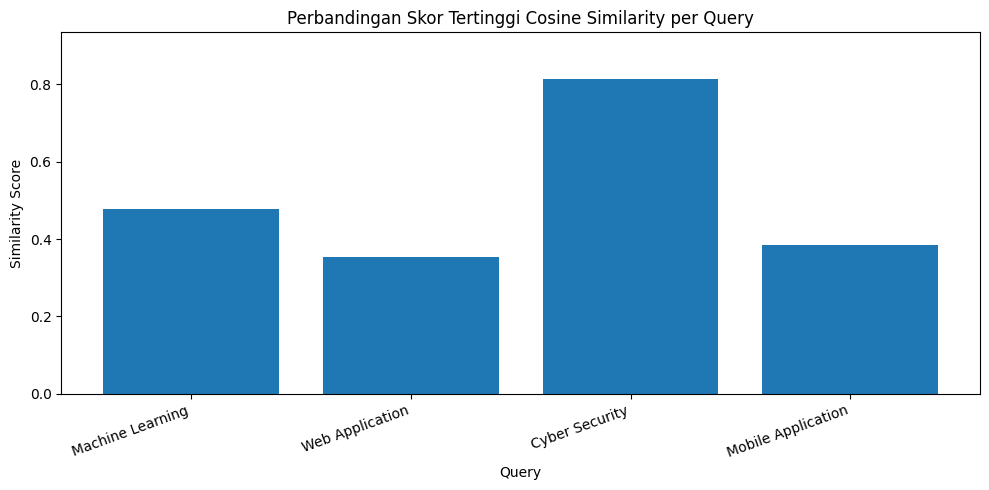

In [15]:
# =========================================================
# CELL 15 - GRAFIK BATANG SKOR TERTINGGI COSINE SIMILARITY
# Gambar 4.1: Perbandingan Skor Tertinggi Cosine Similarity per Query
# =========================================================
import matplotlib.pyplot as plt

query_files = [
    ("Machine Learning", "similarity_score_machine_learning.csv"),
    ("Web Application", "similarity_score_web_application.csv"),
    ("Cyber Security", "similarity_score_cyber_security.csv"),
    ("Mobile Application", "similarity_score_mobile_application.csv"),
]

chart_rows = []

for query_label, filename in query_files:
    csv_path = os.path.join(results_dir, filename)
    cosine_df = pd.read_csv(csv_path)
    top_row = cosine_df.sort_values("similarity_score", ascending=False).iloc[0]

    chart_rows.append({
        "query": query_label,
        "similarity_score": float(top_row["similarity_score"]),
        "article_id": int(top_row["id"]),
        "title": top_row["title"],
        "source_file": filename,
    })

chart_df = pd.DataFrame(chart_rows)
display(chart_df[["query", "article_id", "similarity_score", "source_file"]])

plt.figure(figsize=(10, 5))
plt.bar(chart_df["query"], chart_df["similarity_score"], color="#1f77b4")
plt.title("Perbandingan Skor Tertinggi Cosine Similarity per Query")
plt.xlabel("Query")
plt.ylabel("Similarity Score")
plt.ylim(0, max(chart_df["similarity_score"]) + 0.12)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()